### Importing the libraries

In [7]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import tensorflow_datasets as tfds
import seaborn as sns
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

### Loading the EMNIST dataset

In [ ]:
(ds_train, ds_test), ds_info = tfds.load(
    'emnist/byclass',
    split=['train', 'test'],
    shuffle_files=True,
    as_supervised=True,
    with_info=True
)

# Number of classes and label mapping according to the byclass dataset
num_classes = ds_info.features['label'].num_classes
label_mapping = "0123456789ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz"

### Displaying some examples from dataset

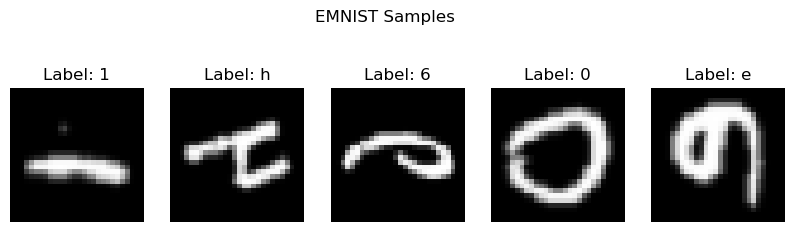

In [9]:
plt.figure(figsize=(10, 3))
for i, (image, label) in enumerate(ds_train.take(5)):
    plt.subplot(1, 5, i + 1)
    plt.imshow(tf.squeeze(image), cmap='gray')
    label_val = label.numpy()
    character = label_mapping[label_val]

    plt.title(f"Label: {character}")
    plt.axis('off')

plt.suptitle("EMNIST Samples")
plt.show()

### Preprocessing the data

In [10]:
def preprocess_byclass(image, label):
    image = tf.cast(image, tf.float32) / 255.0  # Normalize to [0,1]
    return image, label

batch_size = 128

ds_train = ds_train.map(preprocess_byclass).shuffle(10000).batch(batch_size).prefetch(tf.data.AUTOTUNE)
ds_test  = ds_test.map(preprocess_byclass).batch(batch_size).prefetch(tf.data.AUTOTUNE)

### CNN Model Architecture

In [ ]:
def create_cnn_model(num_classes):
    return tf.keras.Sequential([
        # Data augmentation block
        tf.keras.layers.Input(shape=(28, 28, 1)),
        tf.keras.layers.RandomRotation(0.1), # Random rotations
        tf.keras.layers.RandomZoom(0.1),     # Random zooms
        tf.keras.layers.RandomTranslation(height_factor=0.1, width_factor=0.1), # Random shifts

        # Block 1
        tf.keras.layers.Conv2D(32, (3,3), activation='relu'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D((2,2)),

        # Block 2
        tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D((2,2)),

        # Block 3
        tf.keras.layers.Conv2D(128, (3,3), padding='same', activation='relu'),
        tf.keras.layers.BatchNormalization(),

        # Flatten and Classify
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(256, activation='relu'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(num_classes, activation='softmax')
    ])

### Train on dataset

In [ ]:
# Create and compile the model
model = create_cnn_model(num_classes)
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Callbacks for smarter training
early_stopping = EarlyStopping(monitor='val_loss', patience=4, verbose=1, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, verbose=1, min_lr=0.00001)

print("\nTraining on EMNIST Dataset...")
history = model.fit(
    ds_train,
    epochs=25,
    validation_data=ds_test,
    callbacks=[early_stopping, reduce_lr]
)


Training on EMNIST Dataset with Augmentation and Callbacks...
Epoch 1/25
5453/5453 ━━━━━━━━━━━━━━━━━━━━ 526s 96ms/step - accuracy: 0.7759 - loss: 0.6967 - val_accuracy: 0.8099 - val_loss: 0.5500 - learning_rate: 0.0010
Epoch 2/25
5453/5453 ━━━━━━━━━━━━━━━━━━━━ 1607s 295ms/step - accuracy: 0.8207 - loss: 0.5165 - val_accuracy: 0.8267 - val_loss: 0.4770 - learning_rate: 0.0010
Epoch 3/25
5453/5453 ━━━━━━━━━━━━━━━━━━━━ 483s 89ms/step - accuracy: 0.8305 - loss: 0.4829 - val_accuracy: 0.8327 - val_loss: 0.4634 - learning_rate: 0.0010
Epoch 4/25
5453/5453 ━━━━━━━━━━━━━━━━━━━━ 1203s 221ms/step - accuracy: 0.8357 - loss: 0.4642 - val_accuracy: 0.8419 - val_loss: 0.4266 - learning_rate: 0.0010
Epoch 5/25
5453/5453 ━━━━━━━━━━━━━━━━━━━━ 577s 106ms/step - accuracy: 0.8389 - loss: 0.4533 - val_accuracy: 0.8478 - val_loss: 0.4160 - learning_rate: 0.0010
Epoch 6/25
5453/5453 ━━━━━━━━━━━━━━━━━━━━ 589s 108ms/step - accuracy: 0.8416 - loss: 0.4448 - val_accuracy: 0.8371 - val_loss: 0.4437 - learning_ra

### Visualizing Model Predictions

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step 


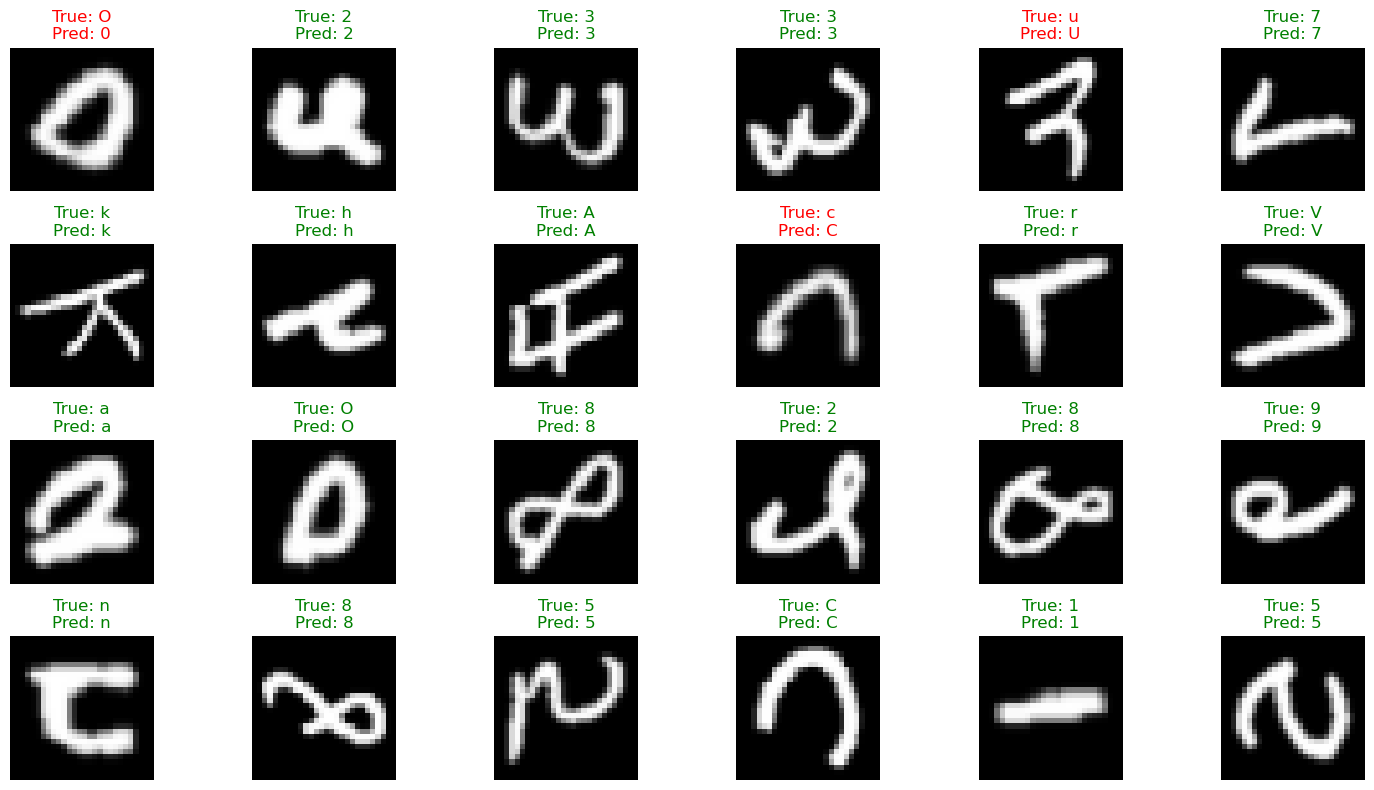

In [ ]:
for images, labels in ds_test.take(1):
    predictions = model.predict(images)
    predicted_labels = np.argmax(predictions, axis=1)

    plt.figure(figsize=(15, 8))
    for i in range(24):
        plt.subplot(4, 6, i + 1)
        plt.imshow(tf.squeeze(images[i]), cmap='gray')
        
        true_label = label_mapping[labels[i].numpy()]
        pred_label = label_mapping[predicted_labels[i]]

        color = 'green' if true_label == pred_label else 'red'
        plt.title(f"True: {true_label}\nPred: {pred_label}", color=color)
        plt.axis('off')
    plt.tight_layout()
    plt.show()
    break

### Creating the Confusion Matrix

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
4/4 ━━━━━━━━

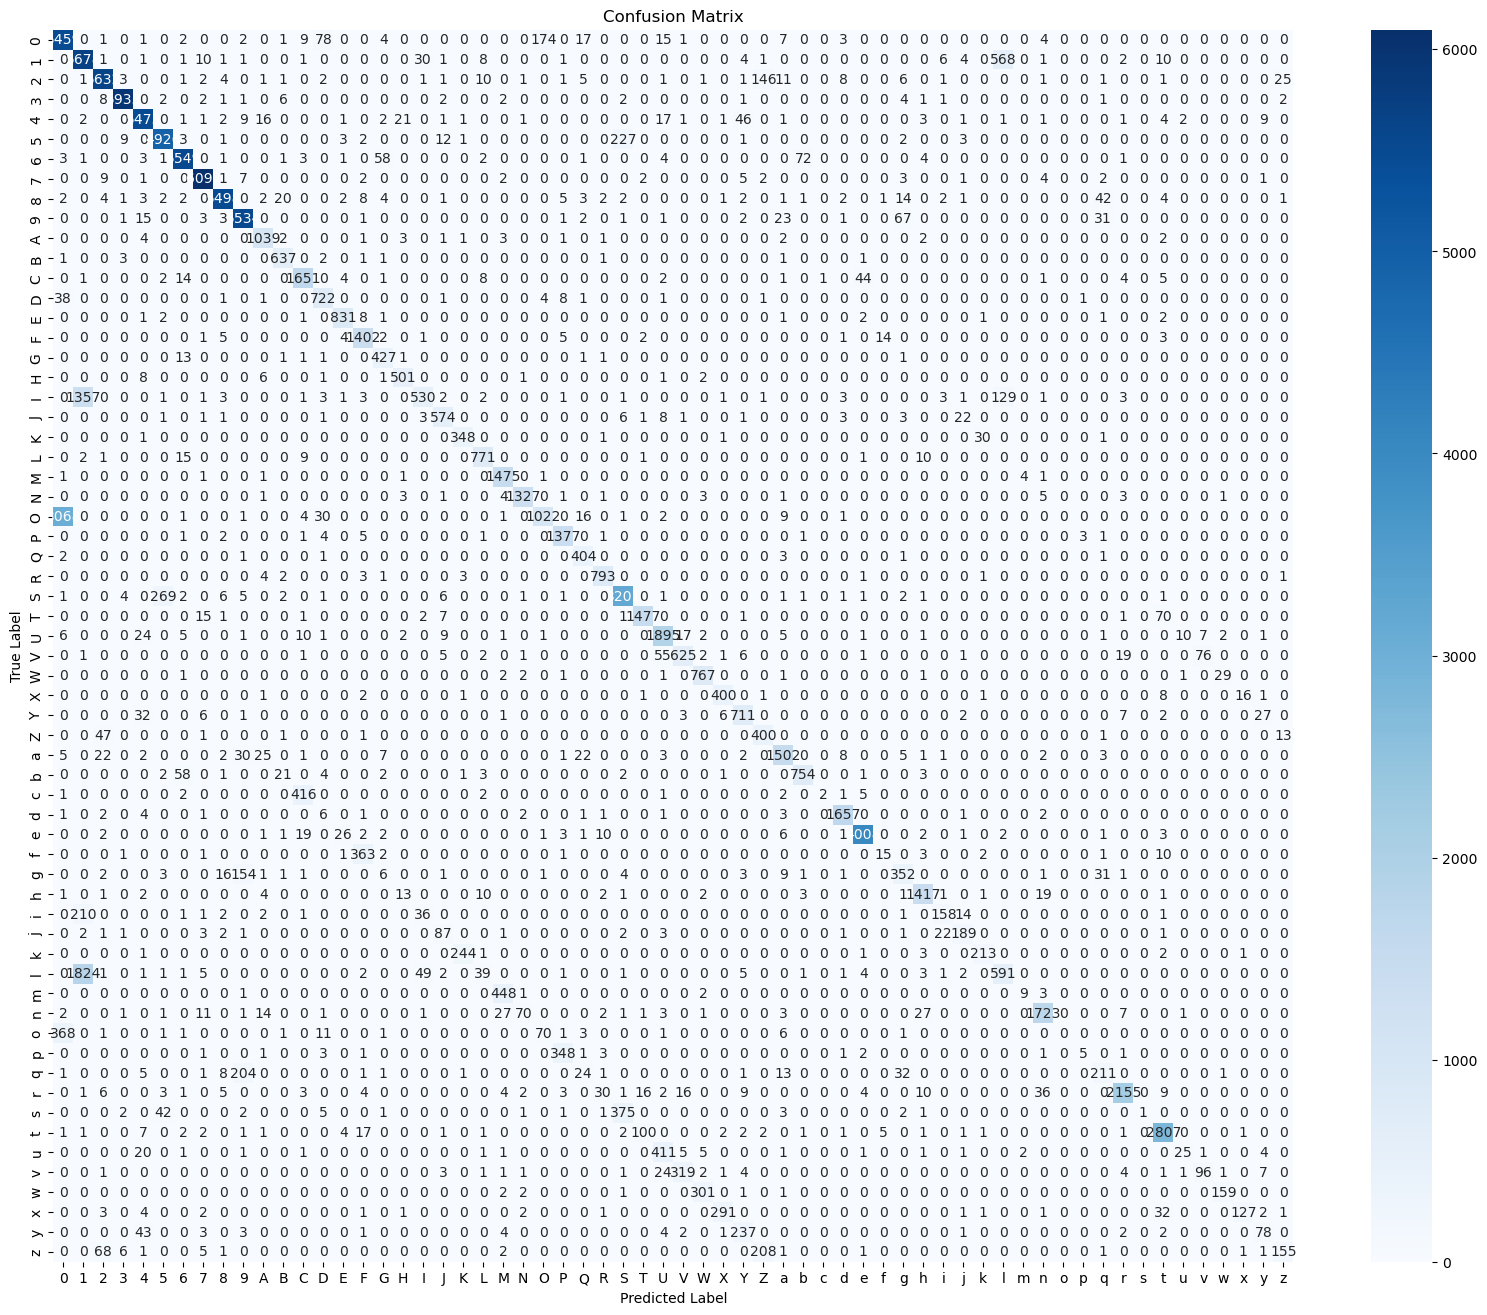

In [14]:
from sklearn.metrics import confusion_matrix

all_true_labels = []
all_pred_labels = []

for images, labels in ds_test:
    predictions = np.argmax(model.predict(images), axis=1)
    all_true_labels.extend(labels.numpy())
    all_pred_labels.extend(predictions)

cm = confusion_matrix(all_true_labels, all_pred_labels)

plt.figure(figsize=(20, 16))
label_names = list(label_mapping)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_names, yticklabels=label_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

### Saving Model

In [15]:
model.save('emnist_cnn_62_class_v2.h5')
print("Model saved successfully!")

Model saved successfully!
